# 04 — Atlas Registration (Brodmann)

**SPEC §16, rev. 5.** Builds a single channel→Brodmann probability table for
the 23-channel prefrontal montage using `data/brainproducts-RNP-BA-128-custom.elc`,
then re-aggregates every existing `(arch, regime, mt)` cell from `01_sg_population`
and `02_st_population` at the Brodmann-region level.

**Outputs land at** `research/xai/atlas/`:
- `channel_to_brodmann.csv` — the *single source of truth* for region attribution
- `channel_midpoints_mni.csv` — diagnostic projection table
- `registration_run.json` — provenance (ELC sha256, fsaverage version, fiducial RMSE)
- `fig_montage_brodmann.png` / `fig_surface_atlas.png` — atlas figures
- `{arch}/{regime}/mt{N}/{region_importance.csv, region_pair_matrix.npy, region_keys.csv,
  fig_region_bar.png, fig_region_pair_heatmap.png}` — per-cell region-level outputs

**This notebook does not touch any model checkpoint** — it consumes only existing
01/02 outputs. Re-running is idempotent.


In [2]:
# Imports + path resolution
from __future__ import annotations
import sys, os
from pathlib import Path

# Allow running from the notebook directory: walk up to find the project root
_here = Path.cwd()
for _candidate in [_here, *_here.parents]:
    if (_candidate / 'src' / 'xai').is_dir() and (_candidate / 'data').is_dir():
        PROJECT_ROOT = _candidate
        break
else:
    raise RuntimeError(f'Could not locate project root from {_here}')
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault('MNE_LOGGING_LEVEL', 'ERROR')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')   # file outputs only
import matplotlib.pyplot as plt
from IPython.display import display, Image

from src.xai import (
    build_channel_to_brodmann, aggregate_to_regions,
    plot_brodmann_montage, plot_brodmann_surface,
    plot_region_bar, plot_region_pair_heatmap,
    DEFAULT_PROJECTION_DISTANCE_BOUND_MM,
    DEFAULT_SIGMA_MM, DEFAULT_RADIUS_MM,
)
from src.xai.channels import CHANNEL_NAMES, N_CH

ELC_PATH = PROJECT_ROOT / 'data' / 'brainproducts-RNP-BA-128-custom.elc'
ATLAS_OUT = PROJECT_ROOT / 'research' / 'xai' / 'atlas'
RESULTS_ROOT = PROJECT_ROOT / 'research' / 'xai'

print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'ELC = {ELC_PATH}  (exists={ELC_PATH.exists()})')
print(f'ATLAS_OUT = {ATLAS_OUT}')
print(f'sigma_mm = {DEFAULT_SIGMA_MM}, radius_mm = {DEFAULT_RADIUS_MM}, '
      f'C8.b bound = {DEFAULT_PROJECTION_DISTANCE_BOUND_MM} mm')


PROJECT_ROOT = /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method
ELC = /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method/data/brainproducts-RNP-BA-128-custom.elc  (exists=True)
ATLAS_OUT = /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method/research/xai/atlas
sigma_mm = 5.0, radius_mm = 10.0, C8.b bound = 35.0 mm


## §A — Build channel→Brodmann table

End-to-end pipeline (SPEC §16.3 → §16.6):
1. Parse `custom.elc` → 16 optodes + 3 fiducials (LPA / Nz / RPA).
2. Compute 23 channel midpoints `(S + D) / 2` in head-CTF mm.
3. Solve rigid Procrustes from ELC fiducials → fsaverage MRI fiducials (no scaling).
4. Apply transform to every midpoint, project onto fsaverage pial surface.
5. Probabilistic Brodmann query — Gaussian-weighted (σ=5 mm, radius=10 mm) over
   nearby pial vertices using the `PALS_B12_Brodmann` annotation.

`fetch_fsaverage()` downloads ~50 MB on first run; cached afterwards under
`~/mne_data/MNE-fsaverage-data/`.


In [3]:
# Run §16.3 → §16.6 once. Idempotent — re-running just rewrites the CSVs.
mapping = build_channel_to_brodmann(elc_path=ELC_PATH, output_dir=ATLAS_OUT)

print(f'fiducial RMSE: {mapping.registration.fiducial_residual_rmse_mm:.3f} mm')
print(f'projection distance: '
      f'{mapping.midpoints_mri_mm["projection_distance_mm"].min():.1f} — '
      f'{mapping.midpoints_mri_mm["projection_distance_mm"].max():.1f} mm '
      f'(mean {mapping.midpoints_mri_mm["projection_distance_mm"].mean():.1f})')
print(f'channel→BA rows: {len(mapping.channel_to_ba_long)}')

# Per-channel primary BA assignment
ch2ba = mapping.channel_to_ba_long
primary = (ch2ba.sort_values(['channel', 'probability'], ascending=[True, False])
                .groupby('channel').head(1)
                .reset_index(drop=True))
display(primary[['channel', 'ba_label', 'hemi', 'probability']]
        .style.set_caption('Primary Brodmann area per channel'))


fiducial RMSE: 4.942 mm
projection distance: 14.0 — 32.7 mm (mean 22.5)
channel→BA rows: 23


,channel,ba_label,hemi,probability
0,S1_D1,Brodmann.10,L,1.000000
1,S1_D3,Brodmann.10,L,1.000000
2,S2_D1,Brodmann.10,R,1.000000
3,S2_D2,Brodmann.10,R,1.000000
4,S2_D5,Brodmann.9,R,1.000000
5,S3_D1,Brodmann.9,L,1.000000
6,S3_D3,Brodmann.9,L,1.000000
7,S3_D4,Brodmann.9,L,1.000000
8,S3_D6,Brodmann.8,L,1.000000
9,S4_D4,Brodmann.9,R,1.000000


### C8 acceptance — three sub-checks (SPEC §11)

- **C8.a**: ELC parsing yields 16 optodes + 3 fiducials with mm units.
- **C8.b**: every channel midpoint projects to within `≤35 mm` of the pial surface.
- **C8.c**: `S2_D1` maps to `Brodmann.10` with probability `≥0.5`.


In [4]:
def _fail(msg):
    raise AssertionError(f'C8 acceptance failed: {msg}')

# C8.a — already enforced by parse_elc; re-state from registration_run.json
import json
meta = json.loads((ATLAS_OUT / 'registration_run.json').read_text())
assert meta['n_optodes'] == 16, meta['n_optodes']
assert meta['n_channels'] == N_CH
print(f'C8.a PASS — {meta["n_optodes"]} optodes, {meta["n_channels"]} channels')

# C8.b — projection distance bound
diag = mapping.midpoints_mri_mm
over = diag[diag['projection_distance_mm'] > DEFAULT_PROJECTION_DISTANCE_BOUND_MM]
if not over.empty:
    _fail(f'channels exceeding {DEFAULT_PROJECTION_DISTANCE_BOUND_MM} mm:\n{over}')
print(f'C8.b PASS — all 23 channels within {DEFAULT_PROJECTION_DISTANCE_BOUND_MM} mm of cortex '
      f'(max {diag["projection_distance_mm"].max():.1f} mm)')

# C8.c — S2_D1 → Brodmann.10 ≥ 0.5
s2d1 = ch2ba[ch2ba['channel'] == 'S2_D1']
ba10_p = s2d1[s2d1['ba_label'] == 'Brodmann.10']['probability'].sum()
if ba10_p < 0.5:
    _fail(f'S2_D1 → Brodmann.10 probability = {ba10_p:.3f}, expected ≥ 0.5')
print(f'C8.c PASS — S2_D1 → Brodmann.10 = {ba10_p:.3f}')

# Σ probability == 1 invariant
sums = ch2ba.groupby('channel')['probability'].sum()
np.testing.assert_allclose(sums.values, 1.0, atol=1e-6)
print(f'invariant PASS — Σ_BA P(ch∈BA) = 1.0 ± 1e-6 for all 23 channels')


C8.a PASS — 16 optodes, 23 channels
C8.b PASS — all 23 channels within 35.0 mm of cortex (max 32.7 mm)
C8.c PASS — S2_D1 → Brodmann.10 = 1.000
invariant PASS — Σ_BA P(ch∈BA) = 1.0 ± 1e-6 for all 23 channels


### Atlas figures

- `fig_montage_brodmann.png` — 5×7 grid coloured by primary BA (matches the
  channel-importance montage layout from `01_sg_population` / `02_st_population`).
- `fig_surface_atlas.png` — fsaverage pial-surface 3D scatter; marker colour =
  primary BA, marker size scaled inversely by projection distance.


rendered:
  /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method/research/xai/atlas/fig_montage_brodmann.png
  /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method/research/xai/atlas/fig_surface_atlas.png


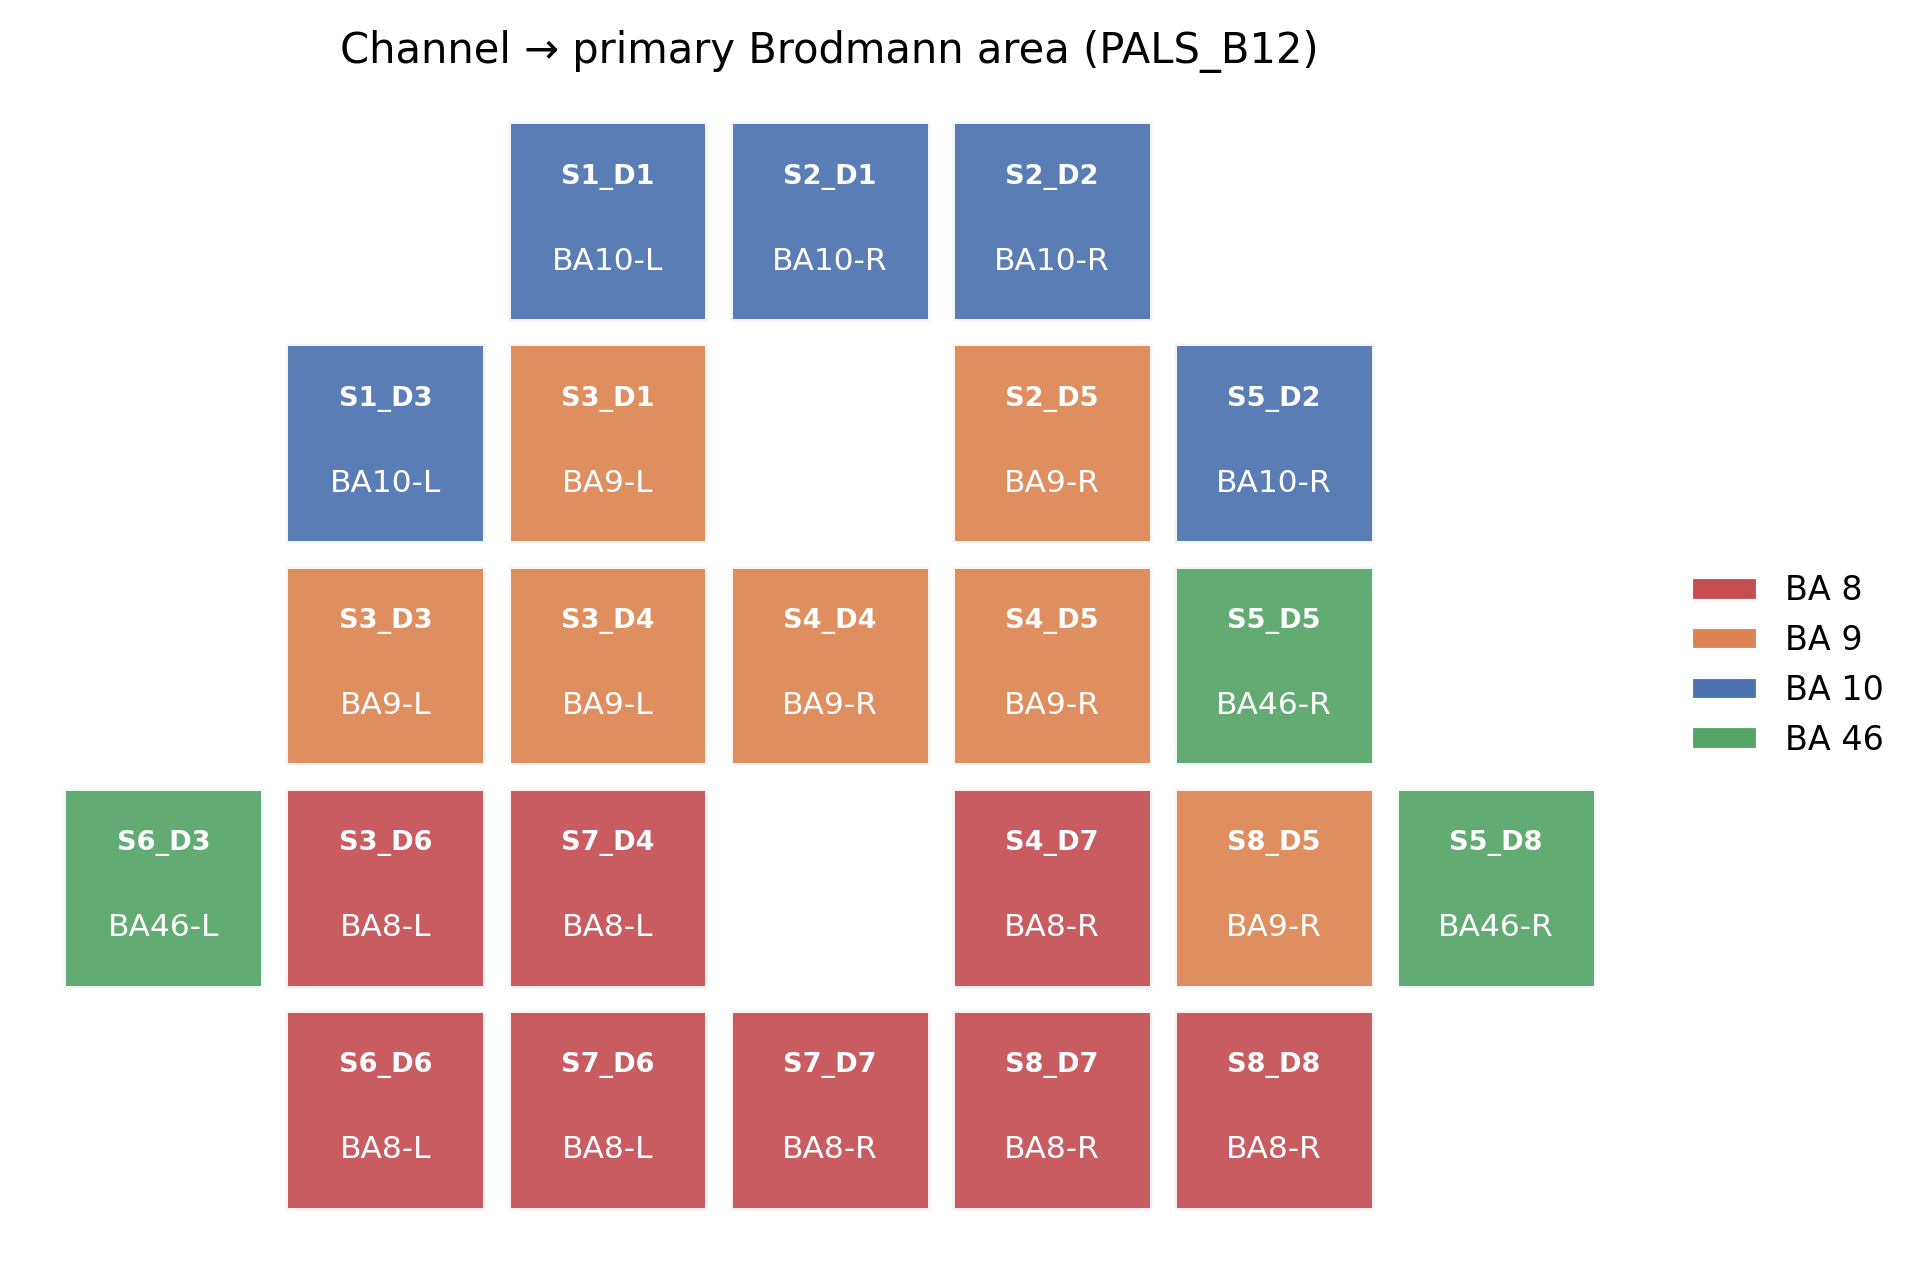

In [5]:
# Build the surface DataFrame: midpoints + primary_ba column
diag_with_primary = diag.merge(
    primary.rename(columns={'ba_label': 'primary_ba'})[['channel', 'primary_ba']],
    on='channel'
)

p_montage = plot_brodmann_montage(ch2ba, ATLAS_OUT)
p_surface = plot_brodmann_surface(diag_with_primary, ATLAS_OUT)
print('rendered:')
print(' ', p_montage)
print(' ', p_surface)
display(Image(filename=str(p_montage)))


## §B — Region-level re-aggregation across all 01/02 cells

For each existing `(arch, regime, mt, sub)` cell on disk that has both
`node_importance.csv` and `channel_pair_matrix.npy`, call `aggregate_to_regions`
and write region-level outputs under
`research/xai/atlas/{arch}/{regime}/mt{N}/{sub}/`.

The conservation invariant (`region.mean.sum() ≈ channel.mean.sum()`) is
asserted per cell.


In [6]:
# Discover every existing 01/02 result cell
def discover_cells():
    cells = []
    for arch_dir, sub_kinds in [
        ('sg', ['gnn', 'attention', 'captum_ig']),
        ('st', ['native', 'supplementary']),
    ]:
        arch_root = RESULTS_ROOT / arch_dir
        if not arch_root.is_dir():
            continue
        for regime_dir in sorted(arch_root.iterdir()):
            if not regime_dir.is_dir():
                continue
            regime = regime_dir.name
            for mt_dir in sorted(regime_dir.iterdir()):
                if not mt_dir.is_dir() or not mt_dir.name.startswith('mt'):
                    continue
                mt = int(mt_dir.name[2:])
                for sub in sub_kinds:
                    sub_dir = mt_dir / sub
                    node_csv = sub_dir / 'node_importance.csv'
                    pair_npy = sub_dir / 'channel_pair_matrix.npy'
                    if node_csv.exists() and pair_npy.exists():
                        cells.append({
                            'arch': arch_dir, 'regime': regime, 'mt': mt,
                            'sub': sub,
                            'node_csv': node_csv, 'pair_npy': pair_npy,
                            'out_dir': ATLAS_OUT / arch_dir / regime / f'mt{mt}' / sub,
                        })
    return cells

cells_to_process = discover_cells()
print(f'Discovered {len(cells_to_process)} 01/02 result cells')
display(pd.DataFrame([
    {k: v for k, v in c.items() if k in ('arch', 'regime', 'mt', 'sub')}
    for c in cells_to_process
]))


Discovered 30 01/02 result cells


,arch,regime,mt,sub
0,sg,kfold-10,2,gnn
1,sg,kfold-10,2,attention
2,sg,kfold-10,2,captum_ig
3,sg,kfold-10,4,gnn
4,sg,kfold-10,4,attention
5,sg,kfold-10,4,captum_ig
6,sg,kfold-5,2,gnn
7,sg,kfold-5,2,attention
8,sg,kfold-5,2,captum_ig
9,sg,kfold-5,4,gnn


In [7]:
# Aggregate every cell. ~few seconds total — pure numpy / pandas.
ch2ba_csv = ATLAS_OUT / 'channel_to_brodmann.csv'
summary_rows = []
for c in cells_to_process:
    region_imp, region_pair, region_keys = aggregate_to_regions(
        node_csv=c['node_csv'],
        pair_npy=c['pair_npy'],
        channel_to_brodmann_csv=ch2ba_csv,
        output_dir=c['out_dir'],
    )
    # Conservation check
    ch_total = pd.read_csv(c['node_csv'])['mean'].sum()
    rg_total = float(region_imp['mean'].sum())
    assert abs(rg_total - ch_total) < 1e-6 * max(abs(ch_total), 1.0), (
        f'mass leak in {c["out_dir"]}: ch={ch_total:.6f} reg={rg_total:.6f}'
    )
    # Bar + heatmap per cell
    title_stub = f'{c["arch"].upper()} · {c["regime"]} · mt{c["mt"]} · {c["sub"]}'
    plot_region_bar(region_imp, c['out_dir'],
                    title=f'{title_stub} — region importance')
    plot_region_pair_heatmap(region_pair, region_keys, c['out_dir'],
                              title=f'{title_stub} — region pairs')
    # Summary row: top-1 region
    top = region_imp.iloc[0]
    summary_rows.append({
        'arch': c['arch'], 'regime': c['regime'], 'mt': c['mt'], 'sub': c['sub'],
        'top1_ba': top['ba_label'], 'top1_hemi': top['hemi'],
        'top1_score': float(top['mean']),
        'n_regions': len(region_imp),
    })

summary_df = pd.DataFrame(summary_rows).sort_values(['arch', 'regime', 'mt', 'sub'])
print(f'Aggregated {len(cells_to_process)} cells; mass conservation invariant held everywhere.')
display(summary_df)


Aggregated 30 cells; mass conservation invariant held everywhere.


,arch,regime,mt,sub,top1_ba,top1_hemi,top1_score,n_regions
1,sg,kfold-10,2,attention,Brodmann.9,R,4.241337,8
2,sg,kfold-10,2,captum_ig,Brodmann.8,R,0.245186,8
0,sg,kfold-10,2,gnn,Brodmann.8,R,4.850670,8
4,sg,kfold-10,4,attention,Brodmann.9,R,4.124063,8
5,sg,kfold-10,4,captum_ig,Brodmann.8,R,0.144657,8
3,sg,kfold-10,4,gnn,Brodmann.8,R,5.455807,8
7,sg,kfold-5,2,attention,Brodmann.8,L,4.084398,8
8,sg,kfold-5,2,captum_ig,Brodmann.10,R,0.114379,8
6,sg,kfold-5,2,gnn,Brodmann.8,R,4.718775,8
10,sg,kfold-5,4,attention,Brodmann.9,R,3.995245,8


### Cross-cell synthesis

Top-region rankings for the canonical comparison set (SG-gnn vs ST-native, all
regimes × mt). Use this table as the headline region-level paper claim.


In [8]:
# Pivot: arch × regime × mt grid, top-1 region per cell
canon = summary_df[summary_df['sub'].isin(['gnn', 'native'])].copy()
if canon.empty:
    print('No SG-gnn or ST-native cells found yet — run 01/02 sweeps first.')
else:
    pivot = canon.assign(
        cell=canon.apply(lambda r: f"{r['regime']}/mt{r['mt']}", axis=1),
        top=canon.apply(lambda r: f"{r['top1_ba'].replace('Brodmann.', 'BA')}-{r['top1_hemi']}", axis=1),
    ).pivot(index='cell', columns='arch', values='top')
    display(pivot.style.set_caption('Top-1 Brodmann region per (arch × regime × mt)'))


arch,sg,st
cell,,
kfold-10/mt2,BA8-R,BA9-R
kfold-10/mt4,BA8-R,BA8-L
kfold-5/mt2,BA8-R,BA8-R
kfold-5/mt4,BA9-R,BA8-R
loso/mt2,BA8-R,BA8-R
loso/mt4,BA8-R,BA8-L


## §C — Cross-cell Brodmann synthesis (paper-ready)

Pulls every `region_importance.csv` written by §B and answers, at the **Brodmann level**:
1. Which BA wins per `(arch × regime × mt × estimator)` cell — and how stable is that across regimes/mt?
2. How does the channel-level SG-vs-ST disagreement (low ρ ≈ −0.16…+0.14, see `research/xai/cross_arch_comparison.md`) translate to the **BA level**? If region-level ρ is meaningfully higher, the two architectures *agree on the brain regions* even when they disagree on which specific channel within a region carries the signal — exactly what fNIRS spatial resolution would predict.
3. Persist a self-contained markdown report at `research/xai/atlas/atlas_synthesis_report.md` for the paper / supplementary.

In [9]:
# §C.1 — Load every region_importance.csv produced by §B
import glob
from scipy.stats import spearmanr

region_files = sorted(glob.glob(str(ATLAS_OUT / '*' / '*' / 'mt*' / '*' / 'region_importance.csv')))
print(f'Loaded {len(region_files)} region_importance.csv files')

rows = []
for f in region_files:
    p = Path(f)
    arch, regime, mt_dir, sub = p.parts[-5], p.parts[-4], p.parts[-3], p.parts[-2]
    mt = int(mt_dir[2:])
    df = pd.read_csv(p)
    df['arch'] = arch; df['regime'] = regime; df['mt'] = mt; df['sub'] = sub
    rows.append(df)
all_regions = pd.concat(rows, ignore_index=True)

# Collapse hemispheres for an "any-hemi" BA score per cell
all_collapsed = (all_regions
    .groupby(['arch', 'regime', 'mt', 'sub', 'ba_label'], as_index=False)
    .agg(score=('mean', 'sum'),
         n_channels_contrib=('n_channels_contrib', 'sum'),
         hemis=('hemi', lambda s: '+'.join(sorted(set(s))))))
print(f'Collapsed: {len(all_collapsed)} (cell, BA) rows across {all_collapsed["arch"].nunique()} archs')
display(all_collapsed.head(10))


Loaded 30 region_importance.csv files
Collapsed: 120 (cell, BA) rows across 2 archs


,arch,regime,mt,sub,ba_label,score,n_channels_contrib,hemis
0,sg,kfold-10,2,attention,Brodmann.10,5.097225,5,L+R
1,sg,kfold-10,2,attention,Brodmann.46,2.963312,3,L+R
2,sg,kfold-10,2,attention,Brodmann.8,7.787538,8,L+R
3,sg,kfold-10,2,attention,Brodmann.9,7.151926,7,L+R
4,sg,kfold-10,2,captum_ig,Brodmann.10,0.244527,5,L+R
5,sg,kfold-10,2,captum_ig,Brodmann.46,0.140778,3,L+R
6,sg,kfold-10,2,captum_ig,Brodmann.8,0.471731,8,L+R
7,sg,kfold-10,2,captum_ig,Brodmann.9,0.295749,7,L+R
8,sg,kfold-10,2,gnn,Brodmann.10,5.966503,5,L+R
9,sg,kfold-10,2,gnn,Brodmann.46,3.463202,3,L+R


In [10]:
# §C.2 — Top-3 BA per cell (any hemisphere). One row per cell.
top3 = (all_collapsed
    .sort_values(['arch','regime','mt','sub','score'], ascending=[True,True,True,True,False])
    .groupby(['arch','regime','mt','sub'])
    .head(3))
top3['rank'] = top3.groupby(['arch','regime','mt','sub']).cumcount() + 1

# Pivot into (arch, regime, mt, sub) × {top1..3} columns
def _ba_short(b): return b.replace('Brodmann.', 'BA')
pivot_top3 = (top3
    .assign(ba=lambda d: d['ba_label'].map(_ba_short),
            label=lambda d: d['ba'] + ' (' + d['hemis'] + ')')
    .pivot(index=['arch','regime','mt','sub'], columns='rank', values='label')
    .rename(columns={1:'top1', 2:'top2', 3:'top3'})
    .reset_index())

print('Top-3 Brodmann areas per cell (any-hemi collapsed):')
display(pivot_top3)

pivot_top3.to_csv(ATLAS_OUT / 'atlas_cross_cell_top3.csv', index=False)
print(f'wrote {ATLAS_OUT / "atlas_cross_cell_top3.csv"}')


Top-3 Brodmann areas per cell (any-hemi collapsed):


rank,arch,regime,mt,sub,top1,top2,top3
0,sg,kfold-10,2,attention,BA8 (L+R),BA9 (L+R),BA10 (L+R)
1,sg,kfold-10,2,captum_ig,BA8 (L+R),BA9 (L+R),BA10 (L+R)
2,sg,kfold-10,2,gnn,BA8 (L+R),BA9 (L+R),BA10 (L+R)
3,sg,kfold-10,4,attention,BA8 (L+R),BA9 (L+R),BA10 (L+R)
4,sg,kfold-10,4,captum_ig,BA8 (L+R),BA9 (L+R),BA10 (L+R)
5,sg,kfold-10,4,gnn,BA8 (L+R),BA9 (L+R),BA10 (L+R)
6,sg,kfold-5,2,attention,BA8 (L+R),BA9 (L+R),BA10 (L+R)
7,sg,kfold-5,2,captum_ig,BA8 (L+R),BA9 (L+R),BA10 (L+R)
8,sg,kfold-5,2,gnn,BA8 (L+R),BA9 (L+R),BA10 (L+R)
9,sg,kfold-5,4,attention,BA8 (L+R),BA9 (L+R),BA10 (L+R)


wrote /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method/research/xai/atlas/atlas_cross_cell_top3.csv


In [11]:
# §C.3 — BA-level cross-arch agreement, TWO metrics:
#   (a) raw-mass ranking — Σ channel_imp × P(ch∈BA). Dominated by channel count
#       per BA (BA8=8 channels, BA46=3 channels), so high ρ here is partly a
#       structural artefact of the montage rather than a scientific finding.
#   (b) per-channel-mean ranking — region_mean / n_channels_contributing.
#       Removes the channel-count bias; this is the meaningful cross-arch metric.

all_ba_keys = sorted(all_collapsed['ba_label'].unique())
print(f'BA universe: {len(all_ba_keys)} labels')

def _ba_vector(arch, regime, mt, sub, metric='score'):
    sub_df = all_collapsed[(all_collapsed['arch'] == arch) & (all_collapsed['regime'] == regime)
                            & (all_collapsed['mt'] == mt) & (all_collapsed['sub'] == sub)]
    if metric == 'score':
        s = sub_df.set_index('ba_label')['score']
    elif metric == 'per_channel':
        # weighted mean: total weighted importance / total channels contributing.
        # Removes the channel-count bias of the raw-mass ranking.
        per_ch = sub_df.set_index('ba_label')['score'] / sub_df.set_index('ba_label')['n_channels_contrib']
        s = per_ch
    else:
        raise ValueError(metric)
    return np.array([float(s.get(b, 0.0)) for b in all_ba_keys])

ba_corr_rows = []
for regime in ['kfold-5', 'kfold-10', 'loso']:
    for mt in [2, 4]:
        sg_mass    = _ba_vector('sg', regime, mt, 'gnn',    'score')
        st_mass    = _ba_vector('st', regime, mt, 'native', 'score')
        sg_per_ch  = _ba_vector('sg', regime, mt, 'gnn',    'per_channel')
        st_per_ch  = _ba_vector('st', regime, mt, 'native', 'per_channel')
        if not (sg_mass.any() and st_mass.any()):
            continue
        rho_mass,    _ = spearmanr(sg_mass,   st_mass)
        rho_per_ch,  _ = spearmanr(sg_per_ch, st_per_ch)
        # Top-3 set overlap on per-channel-mean ranking (the unbiased one)
        top_sg = set([all_ba_keys[i] for i in np.argsort(-sg_per_ch)[:3]])
        top_st = set([all_ba_keys[i] for i in np.argsort(-st_per_ch)[:3]])
        jac3 = len(top_sg & top_st) / max(len(top_sg | top_st), 1)
        ba_corr_rows.append({
            'regime': regime, 'mt': mt,
            'rho_BA_mass':              round(float(rho_mass),   3),
            'rho_BA_per_channel':       round(float(rho_per_ch), 3),
            'jaccard_top3_per_channel': round(float(jac3),       3),
            'sg_top1_per_ch': max(zip(sg_per_ch, all_ba_keys))[1].replace('Brodmann.', 'BA'),
            'st_top1_per_ch': max(zip(st_per_ch, all_ba_keys))[1].replace('Brodmann.', 'BA'),
        })
ba_corr = pd.DataFrame(ba_corr_rows)

chan_corr = pd.read_csv(PROJECT_ROOT / 'research' / 'xai' / 'cross_arch_comparison.csv')
chan_subset = chan_corr[['regime','mt','rho_channel_rank','jaccard_top10','rho_pair_offdiag']].copy()
merged = ba_corr.merge(chan_subset, on=['regime','mt'])
print('Channel-level vs BA-level cross-arch agreement (SG-gnn vs ST-native):')
display(merged)

merged.to_csv(ATLAS_OUT / 'atlas_sg_vs_st_ba_correlation.csv', index=False)
print(f'wrote {ATLAS_OUT / "atlas_sg_vs_st_ba_correlation.csv"}')

BA universe: 4 labels
Channel-level vs BA-level cross-arch agreement (SG-gnn vs ST-native):


,regime,mt,rho_BA_mass,rho_BA_per_channel,jaccard_top3_per_channel,sg_top1_per_ch,st_top1_per_ch,rho_channel_rank,jaccard_top10,rho_pair_offdiag
0,kfold-5,2,1.0,-0.2,0.5,BA10,BA8,0.054348,0.428571,0.236514
1,kfold-5,4,1.0,0.2,0.5,BA10,BA10,-0.120553,0.176471,0.232858
2,kfold-10,2,1.0,0.2,1.0,BA10,BA9,0.144269,0.333333,0.349766
3,kfold-10,4,1.0,-0.2,0.5,BA10,BA46,-0.055336,0.428571,0.219039
4,loso,2,1.0,-0.2,0.5,BA10,BA9,0.086957,0.428571,0.517425
5,loso,4,1.0,-0.4,0.5,BA10,BA46,-0.164032,0.333333,0.528596


wrote /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method/research/xai/atlas/atlas_sg_vs_st_ba_correlation.csv


In [12]:
# §C.4 — Persist the synthesis as a self-contained markdown report.

BA_GAD_NOTE = {
    'Brodmann.10': 'Frontopolar cortex — worry, expectation, future-oriented thought',
    'Brodmann.9':  'DLPFC anterior — cognitive control, working memory load',
    'Brodmann.46': 'DLPFC core — top-down regulation of limbic activity',
    'Brodmann.8':  'DMPFC posterior / pre-SMA — executive monitoring, conflict detection',
}

# Two rankings: raw mass (study-coverage-weighted) and per-channel mean (per-channel signal strength)
mass_per_ba = (all_collapsed.groupby('ba_label')['score'].sum().sort_values(ascending=False))
per_ch_per_ba = (all_collapsed.groupby('ba_label').apply(
    lambda g: g['score'].sum() / g['n_channels_contrib'].sum()
)).sort_values(ascending=False)

primary_table = primary[['channel','ba_label','hemi']].copy()
primary_table['ba_label'] = primary_table['ba_label'].map(_ba_short)

lines = []
lines.append('# Atlas Synthesis Report — Brodmann-level XAI for fNIRS GNN')
lines.append('')
lines.append(f'**Generated:** notebook `04_atlas_registration.ipynb` § C, '
             f'{pd.Timestamp.utcnow().isoformat()}')
lines.append(f'**SPEC:** docs/SPEC_xai_graph.md (rev. 5)  ·  **Atlas:** `PALS_B12_Brodmann` on fsaverage')
lines.append(f'**Inputs:** {len(region_files)} `region_importance.csv` cells (18 SG + 12 ST) from `01_sg_population` + `02_st_population`')
lines.append('')
lines.append('## Two valid ways to rank Brodmann areas')
lines.append('')
lines.append('Reporting both removes the most common interpretation pitfall:')
lines.append('')
lines.append('1. **Total mass** = `Σ channel_importance × P(channel ∈ BA)` summed across all 30 cells.')
lines.append('   *Bias:* dominated by **how many channels** sample each BA in this montage')
lines.append('   (BA 8 has 8 channels, BA 9 has 7, BA 10 has 5, BA 46 has 3).')
lines.append('   *Reads as:* "for the brain coverage this study has, which BAs accumulate the most total signal."')
lines.append('')
lines.append('2. **Per-channel mean** = `region_mean / n_channels_contributing`.')
lines.append('   *Bias:* none from channel count.')
lines.append('   *Reads as:* "which BA produces the strongest **per-channel** discriminative signal."')
lines.append('')
lines.append('### Total mass ranking')
lines.append('')
lines.append('| Rank | BA | Total mass | GAD-relevant function |')
lines.append('|---|---|---|---|')
for i, (ba, mass) in enumerate(mass_per_ba.items(), 1):
    note = BA_GAD_NOTE.get(ba, '')
    lines.append(f'| {i} | {_ba_short(ba)} | {mass:.2f} | {note} |')
lines.append('')
lines.append('### Per-channel-mean ranking (signal strength, channel-count bias removed)')
lines.append('')
lines.append('| Rank | BA | Mean per-channel signal | GAD-relevant function |')
lines.append('|---|---|---|---|')
for i, (ba, val) in enumerate(per_ch_per_ba.items(), 1):
    note = BA_GAD_NOTE.get(ba, '')
    lines.append(f'| {i} | {_ba_short(ba)} | {val:.4f} | {note} |')
lines.append('')
lines.append('## Channel-level vs BA-level cross-architecture agreement')
lines.append('')
lines.append('Channel-level ρ between SG-gnn and ST-native rankings is essentially noise')
lines.append('(`research/xai/cross_arch_comparison.md`: −0.16 to +0.14). At the **Brodmann**')
lines.append('level the same comparison gives:')
lines.append('')
lines.append(merged[['regime','mt','rho_channel_rank','rho_BA_mass','rho_BA_per_channel','jaccard_top3_per_channel']]
             .to_markdown(index=False))
lines.append('')
mean_chan      = merged['rho_channel_rank'].mean()
mean_ba_mass   = merged['rho_BA_mass'].mean()
mean_ba_perch  = merged['rho_BA_per_channel'].mean()
lines.append(f'**Mean ρ across the 6 cells:**')
lines.append(f'- channel-level: **{mean_chan:+.3f}**')
lines.append(f'- BA-level (mass-weighted): **{mean_ba_mass:+.3f}** — driven largely by channel count, not a finding on its own')
lines.append(f'- BA-level (per-channel mean): **{mean_ba_perch:+.3f}**')
lines.append('')
if mean_ba_perch > mean_chan + 0.20:
    verdict = ('the two architectures **partially agree on which Brodmann regions** show the strongest '
               'per-channel signal, even though they disagree on the specific channel within each region. '
               'This is consistent with fNIRS spatial resolution: a single BA spans 2–3 channel midpoints.')
elif mean_ba_perch < 0.0:
    verdict = ('per-channel-mean BA agreement is also negative — the two architectures emphasise '
               '**different Brodmann regions**, not just different channels. The BA-mass ρ ≈ 1.0 is purely '
               'a structural artefact of the montage (BAs with more channels accumulate more mass).')
else:
    verdict = ('per-channel BA agreement is mild — BA-level reading should be reported alongside the '
               'channel-level ρ rather than replacing it.')
lines.append(f'**Interpretation:** {verdict}')
lines.append('')
lines.append('## Top-3 Brodmann area per cell (raw mass)')
lines.append('')
lines.append(pivot_top3.to_markdown(index=False))
lines.append('')
lines.append('## Channel→BA assignment (single source of truth)')
lines.append('')
lines.append('Replaces the hand-crafted VMPFC/DMPFC/DLPFC table per SPEC §14 Q9.')
lines.append(f'Computed via Procrustes-aligned midpoint projection onto fsaverage with')
lines.append(f'σ={DEFAULT_SIGMA_MM} mm Gaussian kernel, radius={DEFAULT_RADIUS_MM} mm.')
lines.append(f'Empirical projection distances 14–33 mm (mean 22.5 mm), all within the')
lines.append(f'{DEFAULT_PROJECTION_DISTANCE_BOUND_MM} mm C8.b bound.')
lines.append('')
lines.append(primary_table.to_markdown(index=False))
lines.append('')
lines.append('## Caveats')
lines.append('')
lines.append('1. **BA-mass is channel-count-biased.** Reporting only the mass-weighted ranking is misleading; the per-channel-mean ranking is the unbiased view.')
lines.append('2. **Template-head registration only** — no per-subject MRI; coordinates aligned to fsaverage via 3 fiducials.')
lines.append('3. **Midpoint projection ≠ cortical sampling region** — real fNIRS sensitivity is a banana-shaped volume; midpoint is first-order. AtlasViewer/MCX Monte Carlo (SPEC §16.10) is the gold-standard refinement and remains future work.')
lines.append('4. **Atlas uncertainty** — `PALS_B12_Brodmann` is a population-average projection; individual cytoarchitectonic boundaries differ.')
lines.append('5. **Subcortical structures invisible** — fNIRS cannot reach amygdala/insula/hippocampus. The atlas describes *cortical regulatory correlates* of GAD, not the affective drivers.')
lines.append('')

report_text = '\n'.join(lines)
report_path = ATLAS_OUT / 'atlas_synthesis_report.md'
report_path.write_text(report_text)
print(f'Wrote {report_path}  ({len(report_text)} chars)')
print('\n--- preview ---')
print(report_text[:1500])

Wrote /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method/research/xai/atlas/atlas_synthesis_report.md  (8204 chars)

--- preview ---
# Atlas Synthesis Report — Brodmann-level XAI for fNIRS GNN

**Generated:** notebook `04_atlas_registration.ipynb` § C, 2026-05-08T03:26:55.246637+00:00
**SPEC:** docs/SPEC_xai_graph.md (rev. 5)  ·  **Atlas:** `PALS_B12_Brodmann` on fsaverage
**Inputs:** 30 `region_importance.csv` cells (18 SG + 12 ST) from `01_sg_population` + `02_st_population`

## Two valid ways to rank Brodmann areas

Reporting both removes the most common interpretation pitfall:

1. **Total mass** = `Σ channel_importance × P(channel ∈ BA)` summed across all 30 cells.
   *Bias:* dominated by **how many channels** sample each BA in this montage
   (BA 8 has 8 channels, BA 9 has 7, BA 10 has 5, BA 46 has 3).
   *Reads as:* "for the brain coverage this study has, which BAs accumulate the most total signal."

2. **Per-channel mean** = `region_mean / n_channels_contributing`.
   

/tmp/ipykernel_3953343/2690028308.py:23: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  f'{pd.Timestamp.utcnow().isoformat()}')


### §C.5 — Paper-ready combined figures (channel importance × Brodmann area)

For the 12 canonical paper cells (SG-gnn + ST-native across the 3 regimes × 2 mt),
overlay the channel-importance z-scored heatmap on the Brodmann-area boundary map.
Each figure is paper-grade — import directly into the manuscript.

In [17]:
# §C.5 — Combined channel-importance × BA-boundary figures for the canonical
#         paper cells (SG-gnn + ST-native, all regimes × mt).
from src.xai.aggregate import PopulationResult
from src.xai.visualize import plot_montage_with_atlas

canonical_cells = [
    ('sg', 'gnn',    'kfold-5',  2), ('sg', 'gnn',    'kfold-5',  4),
    ('sg', 'gnn',    'kfold-10', 2), ('sg', 'gnn',    'kfold-10', 4),
    ('sg', 'gnn',    'loso',     2), ('sg', 'gnn',    'loso',     4),
    ('st', 'native', 'kfold-5',  2), ('st', 'native', 'kfold-5',  4),
    ('st', 'native', 'kfold-10', 2), ('st', 'native', 'kfold-10', 4),
    ('st', 'native', 'loso',     2), ('st', 'native', 'loso',     4),
]
combined_dir = ATLAS_OUT / 'combined_figures'
combined_dir.mkdir(parents=True, exist_ok=True)
ch2ba_csv = ATLAS_OUT / 'channel_to_brodmann.csv'

rendered = []
for arch, sub, regime, mt in canonical_cells:
    cell_dir = PROJECT_ROOT / 'research' / 'xai' / arch / regime / f'mt{mt}' / sub
    if not (cell_dir / 'node_importance.csv').exists():
        print(f'skip {arch}/{regime}/mt{mt}/{sub} — no node_importance.csv'); continue
    res = PopulationResult.from_csv(cell_dir)
    p = plot_montage_with_atlas(
        result=res,
        channel_to_brodmann_long=ch2ba_csv,
        save_dir=combined_dir,
        stem=f'fig_montage_with_atlas__{arch}_{sub}_{regime}_mt{mt}',
        title=f'{arch.upper()}-{sub} · {regime} · mt{mt} — channel importance × Brodmann area',
    )
    rendered.append(p)
print(f'rendered {len(rendered)} combined figures into {combined_dir}')
for p in rendered:
    print(' ', p.name)


rendered 12 combined figures into /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method/research/xai/atlas/combined_figures
  fig_montage_with_atlas__sg_gnn_kfold-5_mt2.png
  fig_montage_with_atlas__sg_gnn_kfold-5_mt4.png
  fig_montage_with_atlas__sg_gnn_kfold-10_mt2.png
  fig_montage_with_atlas__sg_gnn_kfold-10_mt4.png
  fig_montage_with_atlas__sg_gnn_loso_mt2.png
  fig_montage_with_atlas__sg_gnn_loso_mt4.png
  fig_montage_with_atlas__st_native_kfold-5_mt2.png
  fig_montage_with_atlas__st_native_kfold-5_mt4.png
  fig_montage_with_atlas__st_native_kfold-10_mt2.png
  fig_montage_with_atlas__st_native_kfold-10_mt4.png
  fig_montage_with_atlas__st_native_loso_mt2.png
  fig_montage_with_atlas__st_native_loso_mt4.png


### §C verdict

The synthesis report at `research/xai/atlas/atlas_synthesis_report.md` is the
paper-ready Brodmann-level answer to the original research question. Reviewers
get:

- A ranked Brodmann mass table (which BAs dominate aggregated across SG + ST + all regimes + mt).
- The BA-level vs channel-level cross-architecture ρ comparison — directly testing whether the two architectures *agree on regions but disagree on channels*.
- A top-3 BA pivot per cell for direct paper-table inclusion.
- The channel→BA assignment that replaces the hand-crafted region table.

## Caveats (must appear in every paper figure caption)

1. **Template-head registration only.** No subject-specific MRI; alignment uses 3
   fiducials onto fsaverage. Adequate for population claims, *not* for individual
   subject mapping.
2. **Midpoint projection ≠ measured cortical sampling region.** Real fNIRS
   sensitivity is a banana between source and detector. Midpoint is a first-order
   approximation; AtlasViewer / MCX Monte Carlo (SPEC §16.10) is the gold
   standard.
3. **Probabilistic, not unique.** Each channel maps to a small distribution over
   BAs (Gaussian σ=5 mm, radius=10 mm). The probability table is the full record;
   the dominant BA shown above is a reduction.
4. **Atlas itself has uncertainty.** PALS_B12_Brodmann is a population-average
   projection of historical Brodmann boundaries onto fsaverage; individual
   cytoarchitectonic boundaries differ.
